# Unsupervised Learning — Complete Masterclass Notes
## Prodigy Training Hub

**Trainer:** Kajola Gbenga  
**Title:** CEO, Prodigy Training Hub  
**Programme:** Data Science & Machine Learning Masterclass  

---

Unsupervised learning finds **hidden structure in unlabeled data** — no target variable (y) is provided.  
The model discovers patterns, clusters, associations, or compressed representations on its own.

### Table of Contents
1. [What is Unsupervised Learning?](#1-what-is-unsupervised-learning)
2. [K-Means Clustering](#2-k-means-clustering)
3. [Hierarchical Clustering](#3-hierarchical-clustering)
4. [DBSCAN](#4-dbscan)
5. [Gaussian Mixture Models (GMM)](#5-gaussian-mixture-models-gmm)
6. [Principal Component Analysis (PCA)](#6-principal-component-analysis-pca)
7. [t-SNE](#7-t-sne)
8. [UMAP](#8-umap)
9. [Autoencoders](#9-autoencoders)
10. [Association Rule Mining (Apriori / FP-Growth)](#10-association-rule-mining)
11. [Anomaly Detection](#11-anomaly-detection)
12. [Evaluation Metrics for Unsupervised Learning](#12-evaluation-metrics)


## 0. Environment Setup

Run this cell first to install and import all required libraries.

In [3]:
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for notebooks without display
# Install required libraries (run once)
# !pip install scikit-learn matplotlib seaborn pandas numpy umap-learn mlxtend

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import (make_blobs, make_moons,
    make_circles, load_iris, load_digits)
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.pipeline import Pipeline

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

COLORS = {
    'blue':   '#378ADD', 'teal':   '#1D9E75',
    'coral':  '#D85A30', 'amber':  '#BA7517',
    'purple': '#534AB7', 'green':  '#639922',
    'pink':   '#D4537E', 'gray':   '#5F5E5A',
}
PALETTE = list(COLORS.values())

print("All libraries loaded.")
print("Prodigy Training Hub | Trainer: Kajola Gbenga | CEO")


All libraries loaded.
Prodigy Training Hub | Trainer: Kajola Gbenga | CEO


---
## 1. What is Unsupervised Learning?

In supervised learning we have (X, y) — labeled pairs.  
In **unsupervised learning** we only have X — **no labels**.  
The algorithm must discover structure by itself.

### Three main paradigms

| Paradigm | Goal | Algorithms |
|---|---|---|
| **Clustering** | Group similar data points together | K-Means, DBSCAN, Hierarchical, GMM |
| **Dimensionality Reduction** | Compress features while preserving structure | PCA, t-SNE, UMAP, Autoencoders |
| **Association Rules** | Find co-occurrence patterns in transactions | Apriori, FP-Growth |
| **Anomaly Detection** | Find rare, unusual data points | Isolation Forest, LOF, One-Class SVM |

### Supervised vs Unsupervised — Key Differences

| Feature | Supervised | Unsupervised |
|---|---|---|
| Labels (y) | Required | Not available |
| Goal | Predict output | Discover structure |
| Evaluation | Accuracy, F1, R² | Silhouette, Inertia, visual |
| Examples | Classification, Regression | Clustering, Compression |

### Workflow

```
Raw unlabeled data  →  Preprocessing (scale, clean)
                              ↓
                   Choose algorithm + fit
                              ↓
            Interpret results (clusters, components, rules)
                              ↓
             Apply insights (segment, compress, flag anomalies)
```


In [4]:
# Demonstrate: same data, very different unsupervised tasks
from sklearn.datasets import make_blobs

np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw data (no labels)
axes[0].scatter(X[:,0], X[:,1], color='#5F5E5A', alpha=0.5, s=20)
axes[0].set_title('Raw Data\n(no labels — unsupervised)')

# After clustering
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km.fit_predict(X)
for c, col in enumerate(PALETTE[:4]):
    axes[1].scatter(X[labels==c,0], X[labels==c,1],
                    color=col, alpha=0.7, s=20, label=f'Cluster {c}')
axes[1].scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
                marker='*', s=200, color='black', zorder=5)
axes[1].set_title('After K-Means Clustering\n(discover groups)')
axes[1].legend(fontsize=8)

# After PCA dimensionality reduction
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
X_1d = pca.fit_transform(X)
axes[2].scatter(X_1d, np.zeros_like(X_1d), c=labels,
                cmap='tab10', alpha=0.6, s=20)
axes[2].set_title('After PCA (2D → 1D)\n(compress dimensions)')
axes[2].set_ylabel('')

plt.suptitle('Unsupervised Learning — Three Tasks on Same Data\n'
             'Prodigy Training Hub | Trainer: Kajola Gbenga', y=1.02)
plt.tight_layout()
plt.savefig('tmp/unsupervised_overview.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()


---
## 2. K-Means Clustering

### What is it?
Partitions data into **K clusters** by iteratively assigning points to the nearest centroid and recomputing centroids.  
The simplest, fastest, and most widely used clustering algorithm.

### Algorithm steps
```
1. Initialise K centroids randomly (K-Means++ is smarter default)
2. Assign each point to the nearest centroid (Euclidean distance)
3. Recompute each centroid = mean of all points in that cluster
4. Repeat steps 2–3 until centroids stop moving (convergence)
```

### When to use
- You know (or can estimate) the number of clusters K
- Clusters are roughly **spherical and similarly sized**
- Large datasets (very fast — O(nKt))
- Customer segmentation, document clustering, image compression

### Avoid when
- Number of clusters K is unknown (use Elbow + Silhouette to estimate)
- Clusters are non-spherical, elongated, or irregular shaped
- Clusters have very different sizes/densities (use DBSCAN or GMM instead)
- Data has categorical features (use K-Modes instead)

### Choosing K — Elbow Method + Silhouette Score
- **Elbow Method**: plot inertia (within-cluster sum of squares) vs K — look for the "elbow"
- **Silhouette Score**: ranges from -1 to 1. Higher = better defined clusters. Peak = best K.

### How to interpret results
| Output | Interpretation |
|---|---|
| **Cluster labels** | Which group each data point belongs to |
| **Centroids** | The "average member" of each cluster |
| **Inertia** | Total within-cluster variance. Lower = tighter clusters |
| **Silhouette score** | Quality of cluster assignment. > 0.5 = good |

### Real-World Use Cases (Nigerian context)
- GTBank / UBA: Customer segmentation by spending behaviour and account activity
- Jumia: Product grouping for recommendation engine
- Lagos State Government: Neighbourhood profiling for resource allocation
- MUSC Health: Patient cohort identification from ED visit patterns
- Dangote: Supply chain route clustering by delivery distance and frequency


In [5]:
# ── K-MEANS — Full Pipeline ──────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(42)

# Nigerian bank customer segmentation example
n = 500
df_bank = pd.DataFrame({
    'monthly_spend_naira':    np.random.exponential(80000, n),
    'transaction_frequency':  np.random.poisson(12, n),
    'account_balance_naira':  np.random.exponential(300000, n),
    'loan_amount_naira':      np.random.exponential(200000, n),
    'months_as_customer':     np.random.randint(1, 120, n),
})

X = df_bank.values
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# ── Elbow + Silhouette to choose K ──────────────────────────────────────────
k_range   = range(2, 11)
inertias  = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sc, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertias, 'o-', color=COLORS['blue'], lw=2)
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].set_title('Elbow Method\n(look for the elbow / kink)')

axes[1].plot(k_range, sil_scores, 's-', color=COLORS['teal'], lw=2)
axes[1].axhline(0.5, color='red', lw=1, linestyle='--', label='Threshold=0.5')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\n(higher = better defined clusters)')
best_k = list(k_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color=COLORS['coral'], lw=2, linestyle='--',
                label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('Choosing K | Prodigy Training Hub | Trainer: Kajola Gbenga', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/kmeans_elbow.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Best K by Silhouette = {best_k} | Score = {max(sil_scores):.4f}")


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/kmeans_elbow.png'

In [ ]:
# ── Fit Final K-Means + Interpret Clusters ───────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_bank['Cluster'] = km_final.fit_predict(X_sc)

print("="*60)
print(f"K-Means Clustering | K={best_k} | GTBank Customer Segments")
print("Prodigy Training Hub | Trainer: Kajola Gbenga")
print("="*60)
print(f"\nCluster sizes:")
print(df_bank['Cluster'].value_counts().sort_index().to_string())

print("\nCluster profiles (mean values):")
profile = df_bank.groupby('Cluster').mean().round(0)
print(profile.to_string())

# Name clusters based on profile
print("\nBusiness interpretation (example):")
for c in sorted(df_bank['Cluster'].unique()):
    bal = profile.loc[c, 'account_balance_naira']
    spd = profile.loc[c, 'monthly_spend_naira']
    n_c = (df_bank['Cluster']==c).sum()
    if bal > profile['account_balance_naira'].median():
        tier = "High-Value"
    else:
        tier = "Standard"
    print(f"  Cluster {c}: {tier} (n={n_c}, "
          f"avg balance=₦{bal:,.0f}, avg spend=₦{spd:,.0f})")


K-Means Clustering | K=6 | GTBank Customer Segments
Prodigy Training Hub | Trainer: Kajola Gbenga

Cluster sizes:
Cluster
0     47
1    118
2    122
3     62
4     51
5    100

Cluster profiles (mean values):
         monthly_spend_naira  transaction_frequency  account_balance_naira  loan_amount_naira  months_as_customer
Cluster                                                                                                          
0                    64063.0                   13.0               945107.0           200176.0                74.0
1                    51809.0                   10.0               220379.0           134579.0                93.0
2                    51781.0                   11.0               256153.0           122426.0                28.0
3                   233867.0                   11.0               237476.0           156838.0                46.0
4                    77061.0                   11.0               199471.0           659955.0              

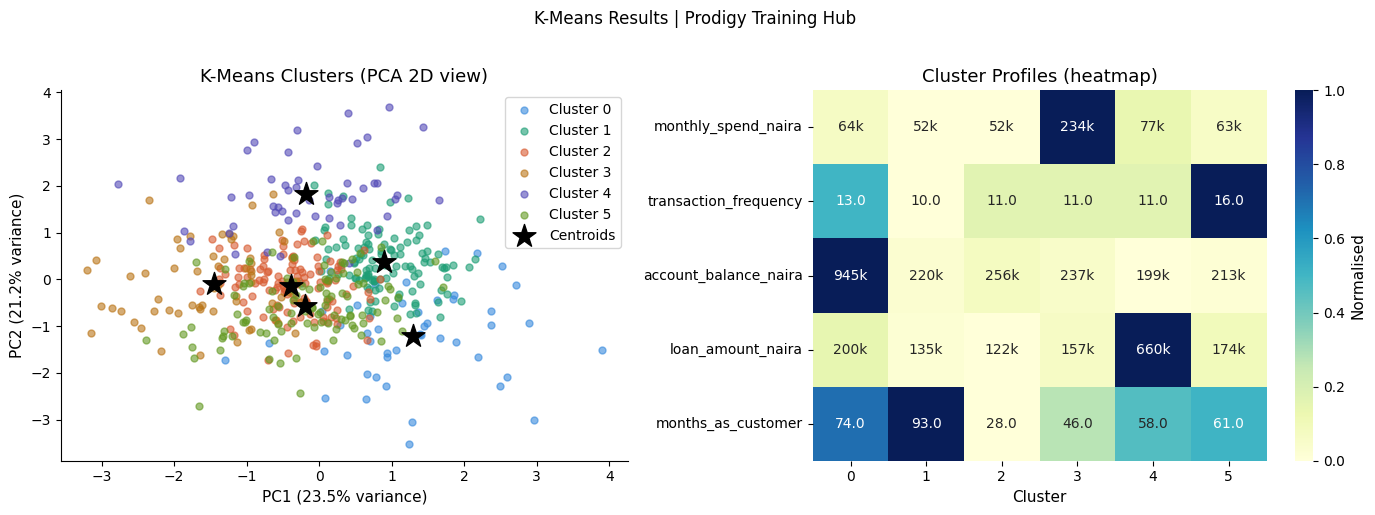

In [ ]:
# ── Visualise Clusters (PCA for 2D projection) ───────────────────────────────
from sklearn.decomposition import PCA

pca_viz = PCA(n_components=2)
X_2d = pca_viz.fit_transform(X_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D scatter
for c in sorted(df_bank['Cluster'].unique()):
    mask = df_bank['Cluster'] == c
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1],
                    color=PALETTE[c % len(PALETTE)], alpha=0.6, s=25, label=f'Cluster {c}')
# Centroids
centers_2d = pca_viz.transform(km_final.cluster_centers_)
axes[0].scatter(centers_2d[:,0], centers_2d[:,1],
                marker='*', s=300, color='black', zorder=10, label='Centroids')
axes[0].set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('K-Means Clusters (PCA 2D view)')
axes[0].legend()

# Feature means per cluster (heatmap)
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
sns.heatmap(profile_norm.T, annot=profile.T.map(lambda x: f'{x/1000:.0f}k'
            if x > 1000 else f'{x:.1f}'),
            fmt='', cmap='YlGnBu', ax=axes[1], cbar_kws={'label':'Normalised'})
axes[1].set_title('Cluster Profiles (heatmap)')
axes[1].set_xlabel('Cluster')

plt.suptitle('K-Means Results | Prodigy Training Hub', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/kmeans_results.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()


---
## 3. Hierarchical Clustering

### What is it?
Builds a **tree of clusters (dendrogram)** by either:
- **Agglomerative (bottom-up)**: start with each point as its own cluster, merge closest pairs iteratively
- **Divisive (top-down)**: start with one cluster, split iteratively (less common)

The dendrogram allows you to choose any number of clusters by cutting at a height.

### When to use
- You **don't know K** in advance (cut the dendrogram at any level)
- Dataset is small to medium (< 10,000 points — O(n²) memory)
- You want to visualize the full cluster hierarchy
- Biological taxonomy, document hierarchy, gene expression analysis

### Linkage methods
| Linkage | Distance between clusters | Effect |
|---|---|---|
| **ward** | Minimizes within-cluster variance | Compact, equal-size clusters (most common) |
| **complete** | Maximum distance between points | Compact, similar-size |
| **average** | Average distance between all pairs | Between ward and single |
| **single** | Minimum distance between any two points | Chaining effect — elongated clusters |

### How to interpret the dendrogram
- **Height (y-axis)**: distance at which clusters were merged. Higher = more dissimilar.
- **Cutting height**: horizontal line that crosses the dendrogram → determines number of clusters.
- **Long vertical lines**: large gap before clusters merge → natural cluster boundary.

### Real-World Use Cases
- Gene expression clustering (which genes behave similarly?)
- Market basket analysis hierarchy (which product categories are related?)
- Language family trees (linguistic clustering)
- Customer complaint topic hierarchy at UBA / GTBank call centres


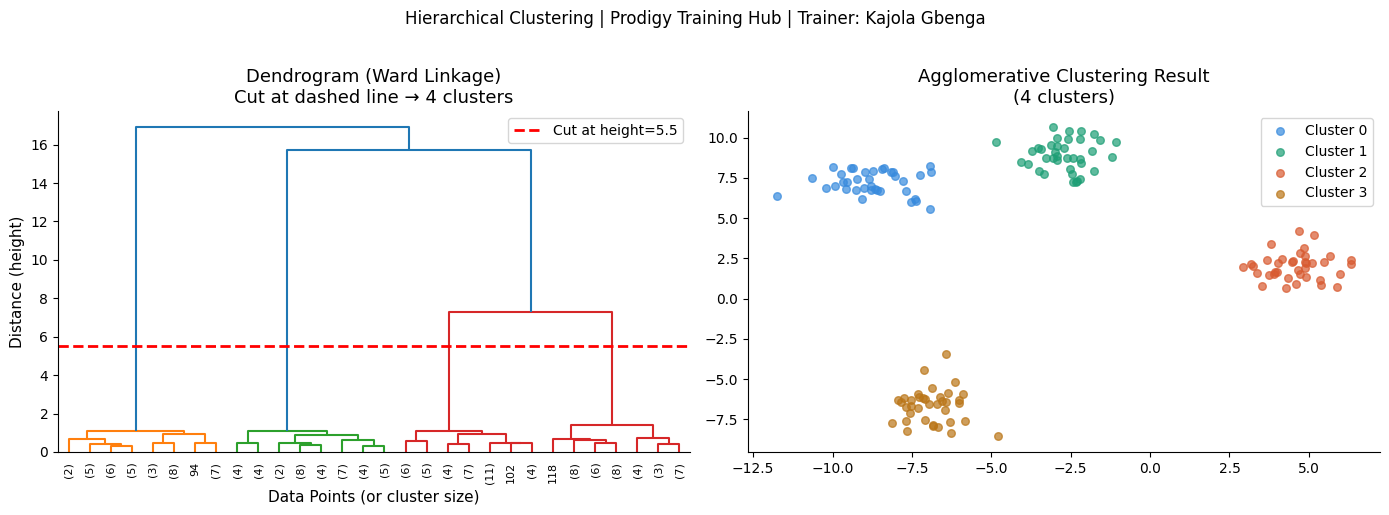

Silhouette Score (Ward, k=4): 0.8118

Linkage comparison:
  ward      : Silhouette = 0.8118
  complete  : Silhouette = 0.8118
  average   : Silhouette = 0.8118
  single    : Silhouette = 0.8118


In [ ]:
# ── HIERARCHICAL CLUSTERING — Dendrogram + AgglomerativeClustering ──────────
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

np.random.seed(42)
X_hier, _ = make_blobs(n_samples=150, centers=4,
                        cluster_std=0.9, random_state=42)
scaler_h = StandardScaler()
X_hier_sc = scaler_h.fit_transform(X_hier)

# Compute linkage matrix (Ward method)
Z = linkage(X_hier_sc, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Dendrogram
dn = dendrogram(Z, ax=axes[0], truncate_mode='lastp', p=30,
                leaf_rotation=90, leaf_font_size=8,
                color_threshold=0.7*max(Z[:,2]))
axes[0].set_title('Dendrogram (Ward Linkage)\n'
                  'Cut at dashed line → 4 clusters')
axes[0].set_xlabel('Data Points (or cluster size)')
axes[0].set_ylabel('Distance (height)')
# Mark cut height
cut_height = 5.5
axes[0].axhline(cut_height, color='red', lw=2, linestyle='--',
                label=f'Cut at height={cut_height}')
axes[0].legend()

# 2. Scatter with clusters
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_h = agg.fit_predict(X_hier_sc)
for c in np.unique(labels_h):
    axes[1].scatter(X_hier[labels_h==c,0], X_hier[labels_h==c,1],
                    color=PALETTE[c % len(PALETTE)], alpha=0.7, s=30, label=f'Cluster {c}')
axes[1].set_title('Agglomerative Clustering Result\n(4 clusters)')
axes[1].legend()

plt.suptitle('Hierarchical Clustering | Prodigy Training Hub | Trainer: Kajola Gbenga',
             y=1.02)
plt.tight_layout()
plt.savefig('/tmp/hierarchical_clustering.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

sil = silhouette_score(X_hier_sc, labels_h)
print(f"Silhouette Score (Ward, k=4): {sil:.4f}")
print("\nLinkage comparison:")
for method in ['ward','complete','average','single']:
    ag = AgglomerativeClustering(n_clusters=4, linkage=method)
    lb = ag.fit_predict(X_hier_sc)
    s  = silhouette_score(X_hier_sc, lb)
    print(f"  {method:10s}: Silhouette = {s:.4f}")


---
## 4. DBSCAN

### What is it?
**Density-Based Spatial Clustering of Applications with Noise.**  
Finds clusters as **dense regions** separated by low-density regions.  
Does not require K to be specified. Automatically identifies **outliers/noise**.

### Core concepts
```
Core point:    Has ≥ min_samples neighbours within radius ε
Border point:  Within ε of a core point but fewer than min_samples neighbours
Noise point:   Not within ε of any core point → labelled as -1 (outlier)
```

### When to use
- **Arbitrary cluster shapes** (moons, rings, elongated blobs)
- You do NOT know the number of clusters in advance
- **Outlier detection** is important
- Spatial / geographic data (GPS coordinates, sensor readings)

### Avoid when
- Clusters have very different densities (DBSCAN struggles)
- Very high dimensional data (distances become unreliable)
- Large datasets with tight ε (use HDBSCAN for large scale)

### Key hyperparameters
| Parameter | Meaning | How to choose |
|---|---|---|
| **eps (ε)** | Maximum distance between two points to be neighbours | Use k-distance graph (elbow in sorted distances) |
| **min_samples** | Minimum points to form a core point | Rule of thumb: 2×n_features or ≥ 5 |

### How to interpret results
- Labels of **-1 = noise/outlier** (not in any cluster)
- Remaining labels 0, 1, 2 … = cluster memberships
- **Number of clusters**: automatically determined (check `len(set(labels)) - (1 if -1 in labels else 0)`)

### Real-World Use Cases
- GPS trajectory clustering: delivery route patterns for Dangote trucks
- Fraud hotspot detection: geographic clustering of ATM fraud incidents
- Social network community detection
- Sensor anomaly detection in manufacturing
- MUSC Health: clustering ED patient arrival patterns with spatial/time coordinates


IndexError: list index out of range

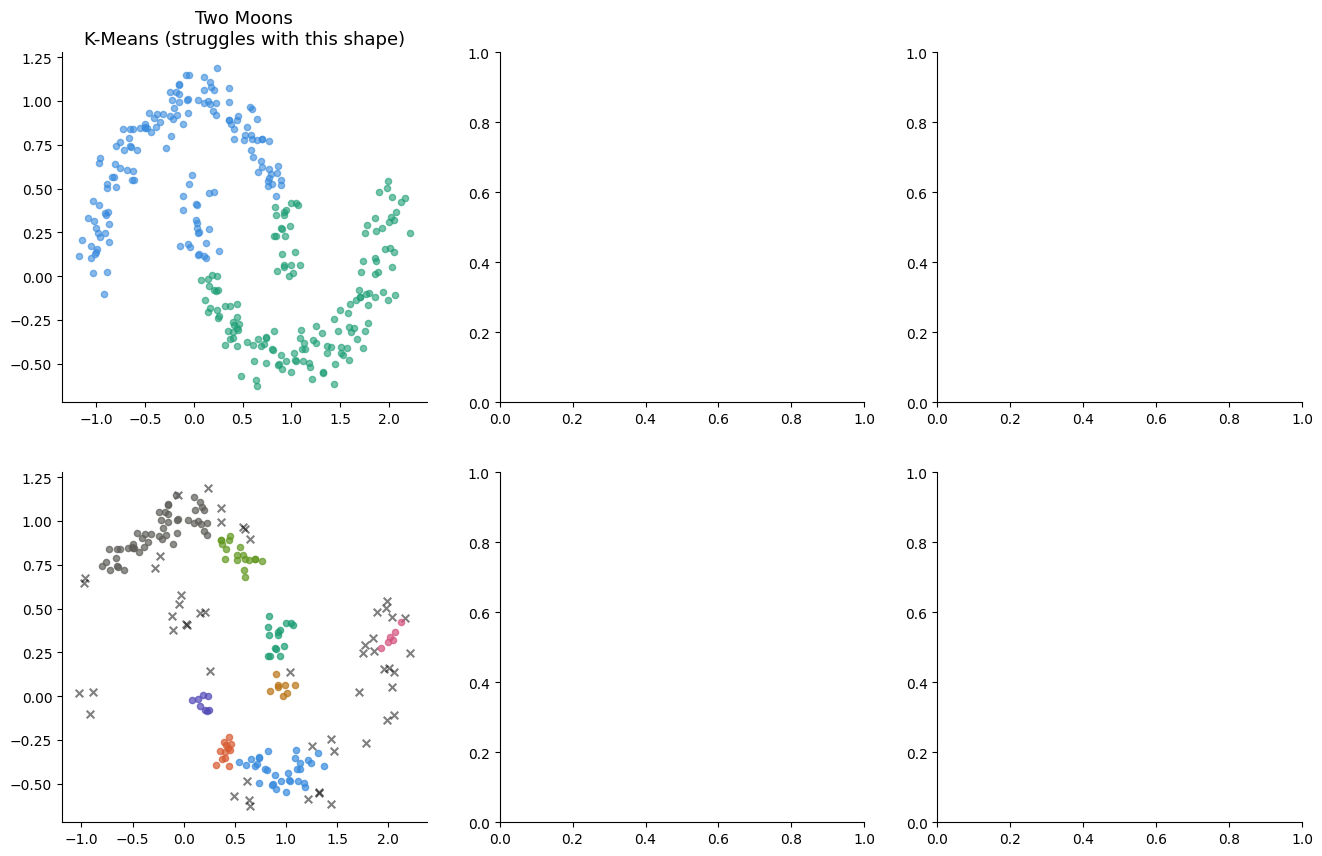

In [ ]:
# ── DBSCAN — Handling Non-Spherical Clusters + Outlier Detection ─────────────
from sklearn.cluster import DBSCAN

np.random.seed(42)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Dataset 1: Two moons
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
# Dataset 2: Two circles
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
# Dataset 3: Blobs with noise
X_blobs, _ = make_blobs(n_samples=280, centers=3, cluster_std=0.5, random_state=42)
X_blobs = np.vstack([X_blobs, np.random.uniform(-6, 6, (20, 2))])   # add noise

datasets  = [X_moons, X_circles, X_blobs]
eps_vals  = [0.15, 0.2, 0.5]
min_s_vals = [5, 5, 5]
titles    = ['Two Moons', 'Concentric Rings', 'Blobs + Noise']
row_labels = ['K-Means (fails)', 'DBSCAN (succeeds)']

for col, (X_d, eps, ms, title) in enumerate(
        zip(datasets, eps_vals, min_s_vals, titles)):
    X_d_sc = StandardScaler().fit_transform(X_d)

    # K-Means (row 0)
    km = KMeans(n_clusters=2 if col < 2 else 3, random_state=42, n_init=10)
    lkm = km.fit_predict(X_d_sc)
    for c in np.unique(lkm):
        axes[0,col].scatter(X_d[lkm==c,0], X_d[lkm==c,1],
                            color=PALETTE[c % len(PALETTE)], alpha=0.6, s=20)
    axes[0,col].set_title(f'{title}\nK-Means (struggles with this shape)')

    # DBSCAN (row 1)
    db = DBSCAN(eps=eps, min_samples=ms)
    ldb = db.fit_predict(X_d_sc)
    n_clusters = len(set(ldb)) - (1 if -1 in ldb else 0)
    n_noise    = (ldb == -1).sum()
    for c in np.unique(ldb):
        if c == -1:
            axes[1,col].scatter(X_d[ldb==c,0], X_d[ldb==c,1],
                                color='black', alpha=0.5, s=30, marker='x',
                                label='Noise/Outliers')
        else:
            axes[1,col].scatter(X_d[ldb==c,0], X_d[ldb==c,1],
                                color=PALETTE[c % len(PALETTE)], alpha=0.7, s=20,
                                label=f'Cluster {c}')
    axes[1,col].set_title(f'{title}\nDBSCAN: {n_clusters} clusters, '
                           f'{n_noise} noise pts')
    axes[1,col].legend(fontsize=7)

for ax, label in zip(axes[:,0], row_labels):
    ax.set_ylabel(label, fontsize=12, fontweight='bold')

plt.suptitle('K-Means vs DBSCAN on Complex Shapes\n'
             'Prodigy Training Hub | Trainer: Kajola Gbenga', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/dbscan_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()


In [ ]:
# ── Choosing epsilon with k-distance graph ───────────────────────────────────
from sklearn.neighbors import NearestNeighbors

X_sample, _ = make_moons(n_samples=400, noise=0.1, random_state=42)
X_sample_sc = StandardScaler().fit_transform(X_sample)

k = 5  # min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(X_sample_sc)
distances, _ = nbrs.kneighbors(X_sample_sc)
k_distances = np.sort(distances[:, k-1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, color=COLORS['blue'], lw=2)
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k}-NN distance')
ax.set_title(f'k-Distance Graph (k={k})\n'
             'Elbow point → good choice for eps')

# Mark suggested elbow
elbow_idx = np.argmax(np.diff(k_distances) > np.std(np.diff(k_distances))*2)
suggested_eps = k_distances[elbow_idx]
ax.axhline(suggested_eps, color='red', lw=2, linestyle='--',
           label=f'Suggested eps ≈ {suggested_eps:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/dbscan_eps_selection.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Suggested eps = {suggested_eps:.3f}")


---
## 5. Gaussian Mixture Models (GMM)

### What is it?
A **probabilistic generative model** that assumes data is generated from a mixture of K Gaussian (Normal) distributions.  
Unlike K-Means (hard assignment), GMM gives **soft probabilistic cluster memberships**.

### Key difference from K-Means
| Feature | K-Means | GMM |
|---|---|---|
| Assignment | Hard (one cluster only) | Soft (probability of each cluster) |
| Cluster shape | Spherical only | Elliptical (flexible covariance) |
| Output | Cluster label | Probability distribution |
| Algorithm | Lloyd's (iterative means) | EM (Expectation-Maximization) |

### When to use
- Clusters may be **elliptical** or have different orientations
- You want **probability of cluster membership** (not just hard labels)
- You have reason to believe data comes from multiple Gaussian distributions
- Density estimation: model the true data distribution

### Covariance types (covariance_type parameter)
| Type | Shape | Parameters | Use when |
|---|---|---|---|
| **spherical** | Circle | 1 per component | Clusters are round, equal size |
| **diag** | Axis-aligned ellipse | n_features per component | Clusters elongated along axes |
| **tied** | Same ellipse for all | Shared matrix | All clusters same shape |
| **full** | Any ellipse | Full matrix per component | Maximum flexibility (default) |

### How to interpret results
- `predict_proba(X)`: gives probability of each cluster for each point
- `score(X)`: log-likelihood of the data under the model — higher = better fit
- Use **BIC or AIC** to choose the number of components K

### Real-World Use Cases
- Customer lifetime value segmentation with overlapping profiles
- Anomaly detection (low probability = unusual point)
- Image segmentation by pixel colour distribution
- Financial return distribution modelling
- Speech recognition (phone/sound modelling)


In [ ]:
# ── GAUSSIAN MIXTURE MODELS — Soft Clustering + BIC selection ────────────────
from sklearn.mixture import GaussianMixture

np.random.seed(42)
# Create non-spherical clusters
X_gmm = np.vstack([
    np.random.multivariate_normal([0, 0],   [[2, 1.5], [1.5, 2]],  120),
    np.random.multivariate_normal([5, 5],   [[1, -0.5], [-0.5, 1]], 100),
    np.random.multivariate_normal([10, 0],  [[3, 0], [0, 0.5]],    80),
])

# BIC to choose number of components
bic_scores = []
aic_scores = []
k_range    = range(1, 9)

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, n_init=3)
    gmm.fit(X_gmm)
    bic_scores.append(gmm.bic(X_gmm))
    aic_scores.append(gmm.aic(X_gmm))

best_k_bic = list(k_range)[np.argmin(bic_scores)]
best_k_aic = list(k_range)[np.argmin(aic_scores)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# BIC/AIC
axes[0].plot(k_range, bic_scores, 'o-', color=COLORS['blue'],  lw=2, label='BIC')
axes[0].plot(k_range, aic_scores, 's-', color=COLORS['coral'], lw=2, label='AIC')
axes[0].axvline(best_k_bic, color=COLORS['blue'],  lw=2, linestyle='--',
                label=f'Best BIC: K={best_k_bic}')
axes[0].set_xlabel('Number of Components K')
axes[0].set_ylabel('Score (lower = better)')
axes[0].set_title('BIC/AIC — Choose K\n(minimum = best)')
axes[0].legend()

# Fit best GMM
gmm_best = GaussianMixture(n_components=best_k_bic, covariance_type='full',
                            random_state=42, n_init=3)
gmm_best.fit(X_gmm)
labels_gmm = gmm_best.predict(X_gmm)
probs_gmm  = gmm_best.predict_proba(X_gmm)

# Scatter
for c in np.unique(labels_gmm):
    axes[1].scatter(X_gmm[labels_gmm==c,0], X_gmm[labels_gmm==c,1],
                    color=PALETTE[c % len(PALETTE)], alpha=0.6, s=25, label=f'Component {c}')
# Draw ellipses
from matplotlib.patches import Ellipse
for k, (mean, cov) in enumerate(zip(gmm_best.means_, gmm_best.covariances_)):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:,order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    for nstd in [1, 2]:
        ell = Ellipse(xy=mean, width=2*nstd*np.sqrt(vals[0]),
                      height=2*nstd*np.sqrt(vals[1]), angle=theta,
                      edgecolor=PALETTE[k % len(PALETTE)], facecolor='none',
                      linewidth=1.5, linestyle='--', alpha=0.7)
        axes[1].add_patch(ell)
axes[1].set_title(f'GMM ({best_k_bic} components, full covariance)\nEllipses = 1σ and 2σ')
axes[1].legend(fontsize=9)

# Soft probabilities for 3 points
axes[2].bar(range(best_k_bic), probs_gmm[0], color=PALETTE[:best_k_bic],
            alpha=0.8, label='Point 1')
axes[2].set_xlabel('Component')
axes[2].set_ylabel('Probability')
axes[2].set_title('Soft Membership Probabilities\n(for one data point)')
axes[2].set_xticks(range(best_k_bic))

plt.suptitle('Gaussian Mixture Models | Prodigy Training Hub | Trainer: Kajola Gbenga',
             y=1.02)
plt.tight_layout()
plt.savefig('/tmp/gmm_results.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

print(f"Best K by BIC: {best_k_bic} | Log-likelihood: {gmm_best.score(X_gmm):.4f}")
print(f"\nSample soft probabilities (first 5 points):")
print(pd.DataFrame(probs_gmm[:5].round(4),
                   columns=[f'P(C{k})' for k in range(best_k_bic)]).to_string())


---
## 6. Principal Component Analysis (PCA)

### What is it?
PCA finds the **directions of maximum variance** in high-dimensional data and projects data onto those directions.  
These new axes are called **Principal Components (PCs)** and are orthogonal (uncorrelated).

### When to use
- **Dimensionality reduction** before feeding into another model (speeds up training, reduces noise)
- **Visualisation**: reduce to 2 or 3 components to plot high-dimensional data
- **Multicollinearity removal**: PCs are uncorrelated by construction
- **Noise reduction**: drop low-variance components that capture only noise
- Feature compression in image processing, NLP, and signal processing

### When NOT to use
- When you need interpretable features (PCs are linear combinations — hard to explain)
- Classification where label discrimination matters more than variance (use LDA instead)
- When data is not linearly structured (use t-SNE/UMAP for visualization)

### How it works (intuition)
```
1. Centre the data (subtract mean)
2. Compute covariance matrix C = XᵀX / (n-1)
3. Find eigenvectors (principal components) and eigenvalues (explained variance)
4. Sort by eigenvalue descending
5. Project data: X_reduced = X · W  where W = top-k eigenvectors
```

### How to interpret results
| Output | Interpretation |
|---|---|
| **explained_variance_ratio_** | % of total variance captured by each PC |
| **Cumulative variance** | How many PCs needed to explain 95% of variance |
| **Loadings (components_)** | How much each original feature contributes to each PC |
| **Scree plot** | Bar chart of explained variance — look for elbow |
| **Biplot** | Scores + loading vectors together |

### Rule of thumb for choosing n_components
- Choose number of PCs that explain **80–95% of total variance**
- Or use scree plot elbow

### Real-World Use Cases
- Face recognition: eigenfaces (PCA on pixel values)
- Finance: factor analysis of stock returns
- SPSS/survey data: reduce many Likert items to fewer latent factors
- Genomics: visualise genetic variation across populations
- MUSC Health: reduce correlated clinical measurements before ML modelling


In [ ]:
# ── PCA — Full Analysis ───────────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

# Load digits dataset (64 features — 8x8 pixel images)
digits = load_digits()
X_dig  = digits.data     # shape (1797, 64)
y_dig  = digits.target

scaler_pca = StandardScaler()
X_dig_sc   = scaler_pca.fit_transform(X_dig)

# Fit PCA with all components
pca_full = PCA(random_state=42)
pca_full.fit(X_dig_sc)

print("="*60)
print("PCA on Handwritten Digits (64 features → compressed)")
print("Prodigy Training Hub | Trainer: Kajola Gbenga")
print("="*60)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cum_var >= 0.95) + 1
n_80 = np.argmax(cum_var >= 0.80) + 1
print(f"Original features: 64")
print(f"Components for 80% variance: {n_80}")
print(f"Components for 95% variance: {n_95}")
print(f"\nTop 5 component explained variance:")
for i, ev in enumerate(pca_full.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {ev:.4f} ({ev*100:.1f}%)")


In [ ]:
# ── Scree Plot + 2D Visualization + Reconstruction ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Scree plot + cumulative variance
axes[0].bar(range(1, 21),
            pca_full.explained_variance_ratio_[:20] * 100,
            color=COLORS['blue'], alpha=0.8, label='Individual')
ax2 = axes[0].twinx()
ax2.plot(range(1, 21), cum_var[:20] * 100, 'o-',
         color=COLORS['coral'], lw=2, label='Cumulative')
ax2.axhline(95, color='gray', lw=1, linestyle='--', label='95%')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
ax2.set_ylabel('Cumulative Variance (%)')
axes[0].set_title('Scree Plot — Explained Variance')
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, labels1+labels2, fontsize=8)

# 2. 2D PCA projection coloured by digit class
pca_2d = PCA(n_components=2, random_state=42)
X_2d_dig = pca_2d.fit_transform(X_dig_sc)
scatter = axes[1].scatter(X_2d_dig[:,0], X_2d_dig[:,1],
                           c=y_dig, cmap='tab10', alpha=0.4, s=10)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('2D PCA Projection\n(64 features → 2 components)')
plt.colorbar(scatter, ax=axes[1], label='Digit class')

# 3. Reconstruction quality vs n_components
recon_errors = []
n_comps_range = [2, 5, 10, 20, 30, 40, 50, 64]
for nc in n_comps_range:
    pca_nc = PCA(n_components=nc, random_state=42)
    X_reduced = pca_nc.fit_transform(X_dig_sc)
    X_recon   = pca_nc.inverse_transform(X_reduced)
    err = np.mean((X_dig_sc - X_recon)**2)
    recon_errors.append(err)

axes[2].plot(n_comps_range, recon_errors, 'o-', color=COLORS['teal'], lw=2)
axes[2].set_xlabel('Number of PCA Components')
axes[2].set_ylabel('Reconstruction MSE')
axes[2].set_title('Reconstruction Error vs Components\n(lower = better reconstruction)')

plt.suptitle('PCA Analysis | Prodigy Training Hub | Trainer: Kajola Gbenga', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/pca_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

# Visualise original vs reconstructed digit
pca_n = PCA(n_components=n_95, random_state=42)
X_reduced_n = pca_n.fit_transform(X_dig_sc)
X_recon_n   = pca_n.inverse_transform(X_reduced_n)

fig, axes2 = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes2[0,i].imshow(X_dig[i].reshape(8,8), cmap='gray_r')
    axes2[0,i].axis('off')
    axes2[1,i].imshow(scaler_pca.inverse_transform(
                      X_recon_n[i].reshape(1,-1)).reshape(8,8), cmap='gray_r')
    axes2[1,i].axis('off')
axes2[0,0].set_ylabel('Original', fontsize=10)
axes2[1,0].set_ylabel(f'Recon\n({n_95} PCs)', fontsize=9)
plt.suptitle(f'PCA Reconstruction: 64 features → {n_95} components (95% variance)\n'
             'Prodigy Training Hub', y=1.05)
plt.savefig('/tmp/pca_reconstruction.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()


---
## 7. t-SNE (t-Distributed Stochastic Neighbor Embedding)

### What is it?
A **non-linear dimensionality reduction** technique designed specifically for **visualization** of high-dimensional data.  
It preserves local neighbourhood structure — nearby points in high dimensions stay nearby in the 2D map.

### How it works (intuition)
```
1. Compute pairwise similarity in HIGH-dimensional space (Gaussian kernel)
2. Compute pairwise similarity in LOW-dimensional space (Student t-distribution)
3. Minimize KL-divergence between the two distributions via gradient descent
4. t-distribution (heavy tails) prevents crowding in 2D
```

### When to use
- **Visualization only** (2D or 3D plots)
- Exploring high-dimensional data (images, word embeddings, genomics)
- After PCA to further refine visualization

### Critical limitations — t-SNE is for visualization ONLY
- **Cannot be used for new data** (no transform() method — no out-of-sample projection)
- **Distances between clusters are NOT meaningful** (only within-cluster neighbourhood)
- **Slow on large datasets** — sample or use PCA first to reduce to ~50 dims
- **Perplexity** heavily affects the output — always try multiple values

### Key hyperparameters
| Parameter | Effect | Typical values |
|---|---|---|
| **perplexity** | Balances local vs global structure. Lower = more local | 5–50 (default 30) |
| **learning_rate** | Gradient descent step size | 10–1000 (default 200) |
| **n_iter** | Number of optimization iterations | 1000+ |

### Real-World Use Cases
- Visualizing word embeddings (Word2Vec, BERT)
- Exploring single-cell RNA-seq data
- Visualizing image feature spaces
- Exploring customer embedding spaces from deep learning models


In [ ]:
# ── t-SNE — Visualisation of High-Dimensional Data ───────────────────────────
from sklearn.manifold import TSNE

# Use digits dataset
# First reduce with PCA to 50 dims (standard practice before t-SNE)
pca_50 = PCA(n_components=50, random_state=42)
X_pca50 = pca_50.fit_transform(X_dig_sc)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. PCA 2D (baseline)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_dig_sc)
sc0 = axes[0].scatter(X_pca2[:,0], X_pca2[:,1], c=y_dig,
                       cmap='tab10', alpha=0.5, s=10)
axes[0].set_title('PCA (2D) — Linear\n(good global structure, poor local)')
plt.colorbar(sc0, ax=axes[0])

# 2. t-SNE perplexity=30
print("Running t-SNE (this may take ~30 seconds)...")
tsne30 = TSNE(n_components=2, perplexity=30, learning_rate=200,
               max_iter=1000, random_state=42)
X_tsne30 = tsne30.fit_transform(X_pca50)
sc1 = axes[1].scatter(X_tsne30[:,0], X_tsne30[:,1], c=y_dig,
                       cmap='tab10', alpha=0.5, s=10)
axes[1].set_title('t-SNE (perplexity=30)\n(excellent local cluster separation)')
plt.colorbar(sc1, ax=axes[1])

# 3. t-SNE perplexity=5 (more local)
tsne5 = TSNE(n_components=2, perplexity=5, learning_rate=200,
              max_iter=1000, random_state=42)
X_tsne5 = tsne5.fit_transform(X_pca50)
sc2 = axes[2].scatter(X_tsne5[:,0], X_tsne5[:,1], c=y_dig,
                       cmap='tab10', alpha=0.5, s=10)
axes[2].set_title('t-SNE (perplexity=5)\n(more fragmented — more local)')
plt.colorbar(sc2, ax=axes[2])

plt.suptitle('PCA vs t-SNE Visualization | Prodigy Training Hub | Trainer: Kajola Gbenga',
             y=1.02)
plt.tight_layout()
plt.savefig('/tmp/tsne_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print("\nt-SNE important reminders:")
print("  1. Use for VISUALIZATION ONLY — cannot project new data")
print("  2. Inter-cluster distances are NOT meaningful")
print("  3. Always try multiple perplexity values (5, 30, 50)")
print("  4. PCA first (to ~50 dims) then t-SNE for speed")


---
## 8. UMAP (Uniform Manifold Approximation and Projection)

### What is it?
A modern non-linear dimensionality reduction algorithm that is **faster than t-SNE** and — crucially — **supports out-of-sample projection**.  
Preserves both **local and global structure** better than t-SNE.

### UMAP vs t-SNE vs PCA
| Feature | PCA | t-SNE | UMAP |
|---|---|---|---|
| Linear? | Yes | No | No |
| Global structure | Excellent | Poor | Good |
| Local structure | Moderate | Excellent | Excellent |
| Speed | Very fast | Slow | Fast |
| New data transform? | Yes | No | **Yes** |
| Parameters | Few | Perplexity | n_neighbors, min_dist |
| Use for modelling? | Yes | No | **Yes** |

### When to use
- Visualization (like t-SNE, but also preserves global structure)
- Dimensionality reduction for downstream ML (supports transform())
- Large datasets (much faster than t-SNE)
- Exploratory data analysis

### Key hyperparameters
| Parameter | Effect | Typical values |
|---|---|---|
| **n_neighbors** | Local vs global balance. Low = local focus | 5–50 (default 15) |
| **min_dist** | Minimum distance in low-dim space. Low = tighter clusters | 0.0–0.5 (default 0.1) |
| **n_components** | Output dimensions (2 for viz, higher for modelling) | 2–50 |
| **metric** | Distance metric | 'euclidean', 'cosine', 'manhattan' |

### Real-World Use Cases
- Same as t-SNE (but better for production pipelines)
- Feature extraction for downstream classification
- Single-cell biology, NLP embedding visualization
- Anomaly detection in compressed space


In [ ]:
# ── UMAP — Visualization + Out-of-Sample Projection ─────────────────────────
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not installed. Run: pip install umap-learn")
    print("Showing sklearn equivalent (t-SNE for now).")

if UMAP_AVAILABLE:
    from umap import UMAP

    reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                   random_state=42)
    X_umap = reducer.fit_transform(X_dig_sc)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    sc = axes[0].scatter(X_umap[:,0], X_umap[:,1], c=y_dig,
                          cmap='tab10', alpha=0.6, s=10)
    axes[0].set_title('UMAP (n_neighbors=15, min_dist=0.1)')
    plt.colorbar(sc, ax=axes[0])

    # Effect of n_neighbors
    for ax, nn in zip(axes[1:], [5, 50]):
        um = UMAP(n_components=2, n_neighbors=nn, min_dist=0.1, random_state=42)
        X_um = um.fit_transform(X_dig_sc)
        sc2 = ax.scatter(X_um[:,0], X_um[:,1], c=y_dig,
                          cmap='tab10', alpha=0.6, s=10)
        ax.set_title(f'UMAP n_neighbors={nn}\n'
                     f'{"(more local focus)" if nn==5 else "(more global focus)"}')
        plt.colorbar(sc2, ax=ax)

    plt.suptitle('UMAP Visualization | Prodigy Training Hub | Trainer: Kajola Gbenga',
                 y=1.02)
    plt.tight_layout()
    plt.savefig('/tmp/umap_visualization.png', dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

    # Out-of-sample projection (unique to UMAP vs t-SNE)
    X_new = X_dig_sc[:5]   # 5 new points
    X_new_projected = reducer.transform(X_new)  # works! t-SNE cannot do this
    print("UMAP supports out-of-sample projection:")
    print(f"  New data shape: {X_new.shape} → Projected: {X_new_projected.shape}")


---
## 9. Autoencoders

### What is it?
A **neural network** trained to reconstruct its own input through a bottleneck layer.  
The bottleneck (latent space) is a **compressed representation** of the data.  
Encoder compresses: X → z (latent). Decoder reconstructs: z → X̂.

### Architecture
```
Input X  →  [Encoder]  →  Latent z (bottleneck)  →  [Decoder]  →  Reconstructed X̂
                                    ↓
                            This is the learned
                        compressed representation
```

### Variants
| Type | Description | Use case |
|---|---|---|
| **Vanilla AE** | Basic encoder-decoder | Dimensionality reduction |
| **Denoising AE** | Trained on corrupted input, output clean | Feature learning, noise removal |
| **Sparse AE** | Sparsity penalty on activations | Feature selection |
| **Variational AE (VAE)** | Latent space is a distribution | Generative modelling |
| **Convolutional AE** | Conv layers for spatial data | Image compression |

### When to use
- Non-linear dimensionality reduction (when PCA is too linear)
- **Anomaly detection**: high reconstruction error = anomaly
- Data denoising
- Feature learning for downstream tasks
- Image compression

### How to interpret results
- **Reconstruction error**: MSE between input and output. Low = normal, High = anomaly
- **Latent space**: visualize with t-SNE/UMAP — related points cluster together
- Monitor **training vs validation loss** to detect overfitting

### Real-World Use Cases
- UBA / GTBank: Credit card fraud detection (anomaly = high reconstruction error)
- Image denoising in medical imaging
- Network intrusion detection
- Recommender systems (learn user preference embeddings)


In [ ]:
# ── AUTOENCODER — sklearn MLP-based + Anomaly Detection ─────────────────────
# Using sklearn MLPRegressor to simulate autoencoder behaviour

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)

# Fraud detection example: 95% normal, 5% anomalous transactions
n_normal = 500
n_fraud  = 25

X_normal = np.random.randn(n_normal, 8)  # normal transactions
X_fraud  = np.random.randn(n_fraud, 8) * 3 + 5  # anomalous (shifted)
X_all    = np.vstack([X_normal, X_fraud])
y_true   = np.array([0]*n_normal + [1]*n_fraud)

scaler_ae = MinMaxScaler()
X_normal_sc = scaler_ae.fit_transform(X_normal)
X_all_sc    = scaler_ae.transform(X_all)

# Train autoencoder ONLY on normal data
# Architecture: 8 → 4 → 2 → 4 → 8
ae = MLPRegressor(
    hidden_layer_sizes=(4, 2, 4),   # bottleneck = 2
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    verbose=False
)
ae.fit(X_normal_sc, X_normal_sc)   # target = input itself!

# Reconstruction error on all data
X_reconstructed = ae.predict(X_all_sc)
recon_error = np.mean((X_all_sc - X_reconstructed)**2, axis=1)

# Set threshold at 95th percentile of normal errors
normal_errors = recon_error[:n_normal]
threshold = np.percentile(normal_errors, 95)

predictions = (recon_error > threshold).astype(int)

print("="*60)
print("Autoencoder — Anomaly Detection (Fraud)")
print("Prodigy Training Hub | Trainer: Kajola Gbenga")
print("="*60)
print(f"Reconstruction error threshold: {threshold:.4f}")
print(f"\nDetection Results:")
print(f"  Normal transactions flagged (false positives): "
      f"{predictions[:n_normal].sum()} / {n_normal}")
print(f"  Fraud detected (true positives): "
      f"{predictions[n_normal:].sum()} / {n_fraud}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Reconstruction error distribution
axes[0].hist(recon_error[:n_normal], bins=30, alpha=0.7,
             color=COLORS['blue'], label='Normal', density=True)
axes[0].hist(recon_error[n_normal:], bins=15, alpha=0.7,
             color=COLORS['coral'], label='Fraud', density=True)
axes[0].axvline(threshold, color='black', lw=2, linestyle='--',
                label=f'Threshold={threshold:.3f}')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Density')
axes[0].set_title('Autoencoder Anomaly Detection\nReconstruction Error Distribution')
axes[0].legend()

# Scatter: error per sample
colors_plot = [COLORS['coral'] if y else COLORS['blue'] for y in y_true]
axes[1].scatter(range(len(recon_error)), recon_error, c=colors_plot, s=20, alpha=0.7)
axes[1].axhline(threshold, color='black', lw=2, linestyle='--',
                label=f'Threshold')
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Reconstruction Error')
axes[1].set_title('Reconstruction Error per Sample')
axes[1].legend()
patches = [mpatches.Patch(color=COLORS['blue'], label='Normal'),
           mpatches.Patch(color=COLORS['coral'], label='Fraud')]
axes[1].legend(handles=patches)

plt.suptitle('Autoencoder | Prodigy Training Hub', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/autoencoder_anomaly.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()


---
## 10. Association Rule Mining (Apriori / FP-Growth)

### What is it?
Discovers **co-occurrence patterns** in transactional data:  
"Customers who buy X also buy Y."  
Used extensively in **market basket analysis** and recommendation systems.

### Key concepts
```
Itemset:    A set of items appearing together in a transaction
Support:    P(A ∩ B) — how often {A, B} appears in all transactions
Confidence: P(B | A) = P(A ∩ B) / P(A) — if A, how likely B?
Lift:       Confidence / P(B) — how much more likely than by chance?
            Lift > 1 = positive association
            Lift = 1 = independent
            Lift < 1 = negative association
```

### Apriori vs FP-Growth
| Feature | Apriori | FP-Growth |
|---|---|---|
| Approach | Candidate generation | Tree-based (FP-tree) |
| Speed | Slow on large data | Much faster |
| Memory | Manageable | Higher |
| Use when | Small dataset | Large dataset |

### How to interpret rules
| Metric | Value | Meaning |
|---|---|---|
| Support = 0.3 | 30% of transactions | Item pair is common |
| Confidence = 0.8 | 80% | When A bought, B bought 80% of the time |
| Lift = 2.5 | 2.5× | Buying A makes buying B 2.5× more likely |

**Focus on high confidence + high lift rules** — these are actionable.

### Real-World Use Cases
- Jumia Nigeria: "Customers who bought this also bought…" recommendations
- GTBank / UBA: Product cross-sell recommendations (insurance + savings)
- Supermarket shelf arrangement (place associated items together)
- Hospital: medication co-prescription analysis
- Telecom: bundle package design (data + calls + SMS)


In [ ]:
# ── ASSOCIATION RULE MINING — Apriori ────────────────────────────────────────
# pip install mlxtend
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MLXTEND = True
except ImportError:
    MLXTEND = False
    print("Install mlxtend: pip install mlxtend")

if MLXTEND:
    np.random.seed(42)

    # Jumia-style transaction dataset
    products = ['Phone', 'Phone Case', 'Charger', 'Earphones',
                'Screen Protector', 'Power Bank', 'Laptop', 'Laptop Bag',
                'Mouse', 'Keyboard', 'Monitor', 'HDMI Cable',
                'T-Shirt', 'Jeans', 'Sneakers', 'Belt']
    
    # Simulate 500 transactions
    transactions = []
    for _ in range(500):
        n_items = np.random.randint(2, 6)
        # Create co-purchase patterns
        basket = []
        r = np.random.rand()
        if r < 0.4:   # tech buyers
            basket = list(np.random.choice(
                ['Phone','Phone Case','Charger','Earphones','Screen Protector','Power Bank'],
                size=np.random.randint(2,5), replace=False))
        elif r < 0.7:  # laptop buyers
            basket = list(np.random.choice(
                ['Laptop','Laptop Bag','Mouse','Keyboard','Monitor','HDMI Cable'],
                size=np.random.randint(2,5), replace=False))
        else:          # fashion buyers
            basket = list(np.random.choice(
                ['T-Shirt','Jeans','Sneakers','Belt'],
                size=np.random.randint(2,4), replace=False))
        transactions.append(basket)
    
    te = TransactionEncoder()
    te_array = te.fit_transform(transactions)
    df_trans  = pd.DataFrame(te_array, columns=te.columns_)
    
    # Mine frequent itemsets
    freq_items = apriori(df_trans, min_support=0.05,
                         use_colnames=True, max_len=3)

    # Workaround for mlxtend 0.25: convert np.str_ to Python str
    freq_items['itemsets'] = freq_items['itemsets'].apply(
        lambda x: frozenset(str(i) for i in x))
    
    # Generate rules
    rules = association_rules(freq_items,
                              num_itemsets=len(freq_items),
                              metric='lift',
                              min_threshold=1.2)
    rules = rules.sort_values('lift', ascending=False)
    
    print("="*65)
    print("Association Rule Mining | Jumia Product Recommendations")
    print("Prodigy Training Hub | Trainer: Kajola Gbenga")
    print("="*65)
    print(f"Transactions: {len(transactions)}")
    print(f"Frequent itemsets found: {len(freq_items)}")
    print(f"Association rules found:  {len(rules)}")
    
    print("\nTop 10 Rules by Lift:")
    top_rules = rules[['antecedents','consequents',
                        'support','confidence','lift']].head(10)
    top_rules = top_rules.copy()
    top_rules['antecedents'] = top_rules['antecedents'].apply(
        lambda x: ', '.join(list(x)))
    top_rules['consequents'] = top_rules['consequents'].apply(
        lambda x: ', '.join(list(x)))
    top_rules[['support','confidence','lift']] =         top_rules[['support','confidence','lift']].round(4)
    print(top_rules.to_string(index=False))


In [ ]:
if MLXTEND:
    # Visualise: Support vs Confidence, coloured by Lift
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    scatter = axes[0].scatter(rules['support'], rules['confidence'],
                               c=rules['lift'], cmap='YlOrRd', s=40, alpha=0.7)
    plt.colorbar(scatter, ax=axes[0], label='Lift')
    axes[0].set_xlabel('Support')
    axes[0].set_ylabel('Confidence')
    axes[0].set_title('Support vs Confidence\n(colour = Lift — darker = stronger association)')
    axes[0].axhline(0.7, color='gray', lw=1, linestyle='--', label='Conf=0.7')
    axes[0].legend()

    # Top rules bar chart
    top10 = rules.head(10).copy()
    top10['rule'] = (top10['antecedents'].apply(lambda x: ', '.join(list(x))) +
                     ' → ' +
                     top10['consequents'].apply(lambda x: ', '.join(list(x))))
    axes[1].barh(top10['rule'], top10['lift'],
                 color=COLORS['teal'], alpha=0.8)
    axes[1].axvline(1, color='red', lw=1.5, linestyle='--', label='Lift=1 (no association)')
    axes[1].set_xlabel('Lift')
    axes[1].set_title('Top 10 Rules by Lift')
    axes[1].legend(fontsize=9)
    plt.setp(axes[1].get_yticklabels(), fontsize=8)

    plt.suptitle('Association Rules | Prodigy Training Hub | Trainer: Kajola Gbenga',
                 y=1.02)
    plt.tight_layout()
    plt.savefig('/tmp/association_rules.png', dpi=120, bbox_inches='tight')
    plt.show()
plt.close()


---
## 11. Anomaly Detection

### What is it?
Identifies **rare, unusual data points** that differ significantly from the majority.  
No labels required — learns the "normal" distribution, then flags deviations.

### Three major approaches

| Approach | Algorithm | How it works |
|---|---|---|
| **Density-based** | LOF (Local Outlier Factor) | Points in low-density regions vs neighbours |
| **Tree-based** | Isolation Forest | Anomalies are easier to isolate (shorter paths) |
| **One-class** | One-Class SVM | Learn a boundary around normal data |
| **Statistical** | Elliptic Envelope | Assume Gaussian, flag statistical outliers |

### When to use each
| Algorithm | Best for |
|---|---|
| **Isolation Forest** | High-dimensional tabular data, large datasets |
| **LOF** | Lower-dimensional data, density-based outliers |
| **One-Class SVM** | When normal data has complex boundary |
| **Elliptic Envelope** | Data approximately Gaussian, few features |

### Contamination parameter
The expected proportion of outliers in data.  
Set to match domain knowledge (e.g., fraud rate = 0.02 for 2% fraud).

### How to interpret results
- Predictions: **-1 = anomaly, 1 = normal** (sklearn convention)
- Anomaly scores: more negative = more anomalous
- **Decision function**: distance from the boundary — farther negative = stronger anomaly

### Real-World Use Cases
- GTBank / First Bank: Credit card fraud detection (real-time)
- MUSC Health: Unusual patient vital signs in ED monitoring
- Dangote: Manufacturing quality control — defective product detection
- Jumia: Fake product listing detection
- UBA Compliance: Unusual transaction pattern flagging (AML)
- Network security: Intrusion detection system


In [ ]:
# ── ANOMALY DETECTION — Four Algorithms Compared ────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

np.random.seed(42)

# Credit card transaction simulation
n_normal = 400
n_fraud  = 20
X_normal_ad = np.random.randn(n_normal, 2) * 2
X_fraud_ad  = np.vstack([
    np.random.uniform(6, 10, (10, 2)),
    np.random.uniform(-9, -6, (10, 2))
])
X_ad  = np.vstack([X_normal_ad, X_fraud_ad])
y_ad  = np.array([1]*n_normal + [-1]*n_fraud)  # 1=normal, -1=fraud

contamination = n_fraud / len(X_ad)

detectors = {
    'Isolation Forest': IsolationForest(contamination=contamination,
                                        random_state=42),
    'LOF':              LocalOutlierFactor(contamination=contamination,
                                           novelty=False),
    'One-Class SVM':    OneClassSVM(nu=contamination),
    'Elliptic Envelope':EllipticEnvelope(contamination=contamination,
                                         random_state=42)
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, det) in zip(axes, detectors.items()):
    if isinstance(det, LocalOutlierFactor):
        preds = det.fit_predict(X_ad)
    else:
        preds = det.fit(X_ad).predict(X_ad)
    
    # Metrics
    tp = ((preds == -1) & (y_ad == -1)).sum()
    fp = ((preds == -1) & (y_ad ==  1)).sum()
    tn = ((preds ==  1) & (y_ad ==  1)).sum()
    fn = ((preds ==  1) & (y_ad == -1)).sum()
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    
    # Plot
    colors_plot = ['red' if p == -1 else 'steelblue' for p in preds]
    ax.scatter(X_ad[:,0], X_ad[:,1], c=colors_plot, alpha=0.6, s=20)
    ax.set_title(f'{name}\nPrec={precision:.2f} Rec={recall:.2f}')
    
    # Legend
    p1 = mpatches.Patch(color='red', label='Flagged')
    p2 = mpatches.Patch(color='steelblue', label='Normal')
    ax.legend(handles=[p1,p2], fontsize=8)

plt.suptitle('Anomaly Detection Comparison | Prodigy Training Hub | Trainer: Kajola Gbenga',
             y=1.02)
plt.tight_layout()
plt.savefig('/tmp/anomaly_detection.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()


In [ ]:
# ── Isolation Forest deep dive + anomaly scores ──────────────────────────────
iso = IsolationForest(contamination=0.05, n_estimators=200,
                       random_state=42, n_jobs=-1)
iso.fit(X_ad)

scores = iso.decision_function(X_ad)  # more negative = more anomalous
preds_iso = iso.predict(X_ad)

print("="*60)
print("Isolation Forest — Detailed Results")
print("Prodigy Training Hub | Trainer: Kajola Gbenga")
print("="*60)
print(f"Total samples:   {len(X_ad)}")
print(f"Flagged as anomaly: {(preds_iso==-1).sum()}")
print(f"True anomalies in data: {(y_ad==-1).sum()}")

print(f"\nAnomaly score range:")
print(f"  Normal transactions:  {scores[:n_normal].min():.3f} to {scores[:n_normal].max():.3f}")
print(f"  Fraud transactions:   {scores[n_normal:].min():.3f} to {scores[n_normal:].max():.3f}")
print("  (More negative = more anomalous)")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(scores[:n_normal], bins=30, alpha=0.7,
        color=COLORS['blue'], label='Normal transactions', density=True)
ax.hist(scores[n_normal:], bins=8, alpha=0.8,
        color=COLORS['coral'], label='Fraud transactions', density=True)
threshold_score = np.percentile(scores, 5)
ax.axvline(threshold_score, color='black', lw=2, linestyle='--',
           label=f'5th percentile threshold = {threshold_score:.3f}')
ax.set_xlabel('Anomaly Score (more negative = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Isolation Forest Anomaly Scores\n'
             'Prodigy Training Hub | Trainer: Kajola Gbenga')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/isolation_forest_scores.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()


---
## 12. Evaluation Metrics for Unsupervised Learning

Unsupervised learning is harder to evaluate — no ground truth labels (y) in most cases.  
We use **internal** metrics (data-driven) and **external** metrics (when labels are available for validation).

### Clustering Evaluation

#### Internal Metrics (no labels needed)
| Metric | Range | Good value | What it measures |
|---|---|---|---|
| **Silhouette Score** | -1 to 1 | Close to 1 | Tightness within clusters vs separation between |
| **Davies-Bouldin Index** | 0 to ∞ | Close to 0 | Ratio of within-cluster to between-cluster distances |
| **Calinski-Harabasz Index** | 0 to ∞ | High | Ratio of between-cluster to within-cluster dispersion |
| **Inertia (K-Means)** | 0 to ∞ | Lower | Sum of squared distances to nearest centroid |

#### External Metrics (ground truth labels available for validation)
| Metric | Range | Good value | Notes |
|---|---|---|---|
| **Adjusted Rand Index (ARI)** | -1 to 1 | Close to 1 | Measures agreement with true labels |
| **Normalized Mutual Info (NMI)** | 0 to 1 | Close to 1 | Information shared between clusters and labels |
| **Homogeneity** | 0 to 1 | Close to 1 | Each cluster contains only one class |
| **Completeness** | 0 to 1 | Close to 1 | All members of a class are in the same cluster |

### Dimensionality Reduction Evaluation
| Metric | What it measures |
|---|---|
| **Explained variance ratio** (PCA) | % of total variance retained |
| **Reconstruction error** (PCA, Autoencoders) | MSE between original and reconstructed |
| **Trustworthiness** | How well local structure is preserved |
| **Downstream task accuracy** | Classification/regression accuracy after reduction |

### Association Rules Evaluation
| Metric | Meaning | Threshold |
|---|---|---|
| Support | Frequency of itemset | > min_support (domain specific, 0.01–0.1) |
| Confidence | Conditional probability | > 0.5 usually |
| Lift | Strength vs chance | > 1 (ideally > 1.5) |


In [ ]:
# ── COMPREHENSIVE CLUSTERING EVALUATION ──────────────────────────────────────
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score,
    normalized_mutual_info_score, homogeneity_score, completeness_score)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import make_blobs

np.random.seed(42)
X_eval, y_true_eval = make_blobs(n_samples=500, centers=4,
                                   cluster_std=0.8, random_state=42)
X_eval_sc = StandardScaler().fit_transform(X_eval)

algorithms = {
    'K-Means (k=4)':     KMeans(n_clusters=4, random_state=42, n_init=10),
    'K-Means (k=3)':     KMeans(n_clusters=3, random_state=42, n_init=10),
    'Hierarchical (k=4)':AgglomerativeClustering(n_clusters=4, linkage='ward'),
    'DBSCAN':            DBSCAN(eps=0.6, min_samples=5),
}

print("="*80)
print("Complete Clustering Evaluation Dashboard")
print("Prodigy Training Hub | Trainer: Kajola Gbenga | CEO")
print("="*80)
print(f"{'Algorithm':<22} {'Sil↑':>6} {'DB↓':>6} {'CH↑':>8} "
      f"{'ARI↑':>6} {'NMI↑':>6} {'Hom↑':>6} {'Comp↑':>6}")
print("-"*80)

results_eval = {}
for name, algo in algorithms.items():
    labels = algo.fit_predict(X_eval_sc)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters < 2:
        print(f"{name:<22} {'--':>6} {'--':>6} {'--':>8} {'--':>6} {'--':>6} {'--':>6} {'--':>6}  (only 1 cluster)")
        continue
    
    # Internal (no ground truth)
    sil = silhouette_score(X_eval_sc, labels)
    db  = davies_bouldin_score(X_eval_sc, labels)
    ch  = calinski_harabasz_score(X_eval_sc, labels)
    
    # External (using true labels for validation)
    ari  = adjusted_rand_score(y_true_eval, labels)
    nmi  = normalized_mutual_info_score(y_true_eval, labels)
    hom  = homogeneity_score(y_true_eval, labels)
    comp = completeness_score(y_true_eval, labels)
    
    results_eval[name] = {
        'Silhouette': sil, 'Davies-Bouldin': db,
        'Calinski-Harabasz': ch, 'ARI': ari,
        'NMI': nmi, 'Homogeneity': hom, 'Completeness': comp,
        'n_clusters': n_clusters
    }
    
    print(f"{name:<22} {sil:>6.3f} {db:>6.3f} {ch:>8.1f} "
          f"{ari:>6.3f} {nmi:>6.3f} {hom:>6.3f} {comp:>6.3f}")

print("-"*80)
print("↑ = higher is better  ↓ = lower is better")


In [ ]:
# ── Full Visual Evaluation Dashboard ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

metrics_to_plot = ['Silhouette', 'Davies-Bouldin', 'ARI', 'NMI',
                   'Homogeneity', 'Completeness']
higher_is_better = [True, False, True, True, True, True]

for ax, metric, hib in zip(axes, metrics_to_plot, higher_is_better):
    names = list(results_eval.keys())
    vals  = [results_eval[n][metric] for n in names]
    colors_bar = []
    best_idx = np.argmax(vals) if hib else np.argmin(vals)
    for i in range(len(vals)):
        colors_bar.append(COLORS['teal'] if i == best_idx else COLORS['blue'])

    bars = ax.bar(range(len(names)), vals, color=colors_bar, alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{metric}\n({"higher ↑" if hib else "lower ↓"} is better)')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Clustering Evaluation Dashboard\n'
             'Prodigy Training Hub | Trainer: Kajola Gbenga | CEO',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/clustering_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()


---
## Summary — Unsupervised Learning Algorithm Guide

### Quick Selection Table

| Task | Algorithm | When to choose |
|---|---|---|
| **Clustering** | K-Means | Fast, known K, spherical clusters |
| **Clustering** | Hierarchical | Unknown K, want dendrogram, small data |
| **Clustering** | DBSCAN | Arbitrary shapes, noise/outliers present |
| **Clustering** | GMM | Soft probabilities, elliptical clusters |
| **Dim. Reduction** | PCA | Linear, interpretable, preprocessing |
| **Visualization** | t-SNE | Best 2D separation, no out-of-sample |
| **Visualization + pipeline** | UMAP | Fast, global structure, supports transform() |
| **Feature learning** | Autoencoder | Non-linear compression, anomaly detection |
| **Pattern mining** | Apriori/FP-Growth | Transaction co-occurrence, recommendations |
| **Anomaly detection** | Isolation Forest | High-dimensional, tabular, large data |
| **Anomaly detection** | LOF | Low-dimensional, density-based |

### Recommended Next Topics
- **Semi-supervised learning**: label propagation with partial labels
- **Self-supervised learning**: contrastive learning, SimCLR, BERT pretraining
- **Clustering + supervised combination**: cluster-then-classify pipelines
- **HDBSCAN**: robust hierarchical DBSCAN for large datasets
- **Variational Autoencoders (VAE)**: generative models and sampling

---

> **Prodigy Training Hub**  
> Trainer: **Kajola Gbenga**  
> Title: CEO, Prodigy Training Hub  
> Programme: Data Science & Machine Learning Masterclass  

*This notebook is the intellectual property of Prodigy Training Hub. Designed for educational use within the Data Science & ML programme.*
